# Creación BD S&P500

La idea es que del dataset con los precios, se tome el último día y se resten 1000 días, después se compare con el otro dataset de tickers para evaluar el sesgo de supervivencia. Los enlaces a dichos datasets se encuentran a continuación:

Dataset con la información de precios: https://www.kaggle.com/datasets/camnugent/sandp500?resource=download

Dataset con la información de tickers: https://github.com/fja05680/sp500

In [1]:
import pandas as pd
import os
import numpy as np
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt


In [2]:
# ---------------------------------------------------------
# BLOQUE 1: Configuración de Rutas y Carga Inicial
# ---------------------------------------------------------
folder_path = r'../data/processed'
path_main = os.path.join(folder_path, 'dataset_with_returns.csv')
path_components = os.path.join(folder_path, 'S&P 500 Historical Components & Changes(01-17-2026).csv')

print("Cargando dataset principal...")
df = pd.read_csv(path_main)
df['date'] = pd.to_datetime(df['date'])

# Aseguramos el orden cronológico para que el recorte de registros sea correcto
df = df.sort_values(['Name', 'date'])

df.head()

Cargando dataset principal...


,date,open,high,low,close,volume,Name,adjusted_price,return_1d
0,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,28.576422,-0.010648
1,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,28.589230,0.000448
2,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,28.672525,0.002914
3,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,28.563612,-0.003799
4,2013-02-15,43.48,44.24,42.21,42.25,14657315,A,27.070713,-0.052266


### Checking if there are dates gaps

In [3]:
def detect_real_gaps(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["Name", "date"])

    nyse = mcal.get_calendar("NYSE")

    gaps = []

    for name, group in df.groupby("Name"):
        group = group.sort_values("date").reset_index(drop=True)

        for i in range(1, len(group)):
            prev_date = group.loc[i-1, "date"]
            curr_date = group.loc[i, "date"]

            valid_days = nyse.valid_days(start_date=prev_date, end_date=curr_date)

            # deberían ser 2: prev y next
            if len(valid_days) > 2:
                gaps.append({
                    "Name": name,
                    "prev_date": prev_date,
                    "date": curr_date,
                    "missing_days": valid_days[1:-1]
                })

    return pd.DataFrame(gaps)
    
detect_real_gaps(df).shape

(17, 4)

### Avoiding survivor bias

To eliminate survivor bias, we first obtain all month-end constituent lists 
for the S&P 500 from January 2013 to December 2018. We consolidate these lists 
into a single binary matrix, indicating whether each stock is an index 
constituent in the subsequent month. In this way, we are able to approximately 
reproduce the S&P 500 composition at any point in time within this period. 
In a second step, for all stocks that have been constituents of the index at 
any time during this interval, we download daily total return indices covering 
the same time frame.

In [4]:
folder_path = r'../data/raw'
path_components = os.path.join(folder_path, 'S&P 500 Historical Components & Changes(01-17-2026).csv')
df_hist_comp = pd.read_csv(path_components)
df_hist_comp['date'] = pd.to_datetime(df_hist_comp['date'])

print(df_hist_comp.head())
print("...")
print(df_hist_comp.tail())

        date                                            tickers
0 1996-01-02  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
1 1996-01-03  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
2 1996-01-04  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
3 1996-01-10  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
4 1996-01-11  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
...
           date                                            tickers
2700 2025-11-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2701 2025-11-28  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2702 2025-12-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2703 2025-12-22  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2704 2026-01-14  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...


In [5]:
df_hist_comp.dtypes

date       datetime64[us]
tickers               str
dtype: object

In [6]:
df.head()
first_date = df.iloc[0]['date']
print(first_date)

last_date = df.iloc[-1]['date']
print(last_date)

2013-02-11 00:00:00
2018-02-07 00:00:00


Creating pandas tables to see which companies were on S&P 500 at the end of the month

In [7]:
# Filtrar por fechas
df_hist_comp = df_hist_comp[(df_hist_comp['date'] >= first_date) & (df_hist_comp['date'] <= last_date)].copy()

# Extraer año y mes
df_hist_comp['year'] = df_hist_comp['date'].dt.year
df_hist_comp['month'] = df_hist_comp['date'].dt.month

# Tomar último día de cada mes
df_month_end = df_hist_comp.groupby(['year', 'month']).tail(1)

# Eliminar la columna 'date'
df_month_end = df_month_end.drop(columns=['date'])

# Reordenar columnas para que year y month queden primero
cols = ['year', 'month'] + [c for c in df_month_end.columns if c not in ['year', 'month']]
df_month_end = df_month_end[cols]

df_month_end = df_month_end.reset_index(drop=True)

# Revisar resultado
print(df_month_end.head())
print("...")
print(df_month_end.tail())

   year  month                                            tickers
0  2013      2  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
1  2013      3  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
2  2013      4  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
3  2013      5  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
4  2013      6  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
...
    year  month                                            tickers
56  2017     10  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
57  2017     11  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
58  2017     12  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
59  2018      1  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
60  2018      2  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...


Creating Binary matrix

In [8]:
all_tickers = set()

for tickers_str in df_hist_comp['tickers']:
    for t in tickers_str.split(','):
        all_tickers.add(t.strip())
all_tickers = sorted(all_tickers)

ticker_dict = {ticker: idx for idx, ticker in enumerate(all_tickers)}


n_months = len(df_month_end)
n_tickers = len(all_tickers)

# matriz de ceros
binary_matrix = np.zeros((n_months, n_tickers), dtype=int)

for i, row in df_month_end.iterrows():
    tickers_in_row = row['tickers'].split(',')  # separa los tickers
    for t in tickers_in_row:
        t = t.strip()  # quitar espacios
        if t in ticker_dict:  # seguridad
            j = ticker_dict[t]  # columna correspondiente
            binary_matrix[i, j] = 1


binary_df = pd.DataFrame(binary_matrix, columns=all_tickers)
binary_df.insert(0, 'year', df_month_end['year'])
binary_df.insert(1, 'month', df_month_end['month'])

print(binary_df.head())

   year  month  A  AABA  AAL  AAP  AAPL  ABBV  ABC  ABT  ...  XL  XLNX  XOM  \
0  2013      2  1     1    0    0     1     1    1    1  ...   1     1    1   
1  2013      3  1     1    0    0     1     1    1    1  ...   1     1    1   
2  2013      4  1     1    0    0     1     1    1    1  ...   1     1    1   
3  2013      5  1     1    0    0     1     1    1    1  ...   1     1    1   
4  2013      6  1     1    0    0     1     1    1    1  ...   1     1    1   

   XRAY  XRX  XYL  YUM  ZBH  ZION  ZTS  
0     1    1    1    1    1     1    0  
1     1    1    1    1    1     1    0  
2     1    1    1    1    1     1    0  
3     1    1    1    1    1     1    0  
4     1    1    1    1    1     1    1  

[5 rows x 619 columns]


### Create rolling windows

#### Paso 1: Definir los bloques de 1000 dias

In [9]:
WINDOW_SIZE = 240

training_days = 750
trading_days = 250

df_rolling_windows = df  

all_dates = pd.bdate_range(start=df['date'].min(), end=df['date'].max())

study_period_days = training_days + trading_days + WINDOW_SIZE

start_idx = 0
study_periods = []

while start_idx + study_period_days <= len(all_dates):
    period_dates = all_dates[start_idx:start_idx + study_period_days]
    
    study_periods.append({
        'block_dates': period_dates,  
    })
    
    start_idx += trading_days  

print(len(study_periods))

1


Solo tendremos 1 periodo de estudio

#### Paso 2: Filtrar tickers usando la matriz binaria

This function is made so it search the companies that were on S&P500 the last month of the 1000 blocks day

In [10]:
def get_tickers_for_period(binary_df, last_train_date):
    year = last_train_date.year
    month = last_train_date.month
    
    row = binary_df[
        (binary_df['year'] == year) &
        (binary_df['month'] == month)
    ]
    
    if row.empty:
        return []
    
    tickers_series = row.drop(columns=['year', 'month']).iloc[0]
    tickers = tickers_series[tickers_series == 1].index.tolist()
    
    return tickers


Create study periods with metadata

In [11]:
study_periods_data = []

for i, period in enumerate(study_periods):
    
    last_train_date = pd.to_datetime(period['block_dates'][-250])
    
    tickers = get_tickers_for_period(binary_df, last_train_date)
    
    df_1240_days = df_rolling_windows[
        (df_rolling_windows['Name'].isin(tickers)) &
        (df_rolling_windows['date'].isin(period['block_dates']))
    ].copy()
    

    # Guardar todo
    study_periods_data.append({
        'period_id': i,
        'tickers': tickers,
        'n_i': len(tickers),
        '1240_days_df': df_1240_days,
        '1240_days_start': period['block_dates'][0],
        '1240_days_end': period['block_dates'][-1],
    })



In [12]:
for sp in study_periods_data:
    print(f"\nStudy Period {sp['period_id']}")
    print(f"n_i: {sp['n_i']}")
    print(f"data range: {sp['1240_days_start']} → {sp['1240_days_end']}")
    print(f"#data rows: {len(sp['1240_days_df'])}")



Study Period 0
n_i: 506
data range: 2013-02-11 00:00:00 → 2017-11-10 00:00:00
#data rows: 551251


### Create rolling windows for each stock

In [13]:
def calculate_returns(df, price_col="price"):
    
    df["return_1d"] = df['return_1d']

    return df

def create_sequences_for_stock_s(df):
    df = calculate_returns(df)
    sequences_for_ticker = []
    dates_for_ticker = [] # NUEVA LISTA

    window_size = WINDOW_SIZE

    # Ajuste de índices para coincidir con Pandas
    for i in range(window_size - 1, len(df)):
        window = df.iloc[i - window_size + 1 : i + 1]["return_1d"].values
        target_date = df.iloc[i]["date"] # CAPTURAMOS LA FECHA DE R_0
        
        window = window.reshape(-1, 1)
        sequences_for_ticker.append(window)
        dates_for_ticker.append(target_date)

    return sequences_for_ticker, dates_for_ticker
         
def build_sequences_dataset_for_study_period(sp):
    sequences = []
    dates = []  # NUEVA LISTA para agrupar las fechas
    tickers = sp.get('tickers', [])
    df_1240_days = sp.get('1240_days_df')
    
    for t in tickers:
        df_ticker = df_1240_days[df_1240_days["Name"] == t]
        
        # Desempaquetamos los dos valores que ahora devuelve la función
        sequences_for_ticker, dates_for_ticker = create_sequences_for_stock_s(df_ticker)
        
        sequences.append(sequences_for_ticker)
        dates.append(dates_for_ticker) # Guardamos las fechas

    # Retornamos ambas listas
    return sequences, dates

# Bucle actualizado para guardar ambos resultados en el diccionario sp
for sp in study_periods_data:
    seqs_built, dates_built = build_sequences_dataset_for_study_period(sp)
    sp["sequences_dataset"] = seqs_built
    sp["dates_dataset"] = dates_built  # Guardamos las fechas en el diccionario
    

In [14]:
def debug_sequences(sp, max_tickers=3, max_sequences=2):
    sequences = sp.get("sequences_dataset", [])
    tickers = sp.get("tickers", [])

    print(f"\nStudy Period {sp['period_id']}")
    print(f"Total tickers: {len(sequences)}")
    for i, (ticker, ticker_sequences) in enumerate(zip(tickers, sequences)):
        if i >= max_tickers:
            break

        print(f"\nTicker: {ticker}")
        print(f"Total sequences: {len(ticker_sequences)}")

        for j, seq in enumerate(ticker_sequences[:max_sequences]):
            print(f"  Seq {j} shape: {seq.shape}")
            print(f"  First 3 values: {seq[:3].flatten()}")

debug_sequences(study_periods_data[0])


Study Period 0
Total tickers: 506

Ticker: A
Total sequences: 960
  Seq 0 shape: (240, 1)
  First 3 values: [-0.01064766  0.0004482   0.00291354]
  Seq 1 shape: (240, 1)
  First 3 values: [ 0.0004482   0.00291354 -0.00379853]

Ticker: AABA
Total sequences: 0

Ticker: AAL
Total sequences: 960
  Seq 0 shape: (240, 1)
  First 3 values: [-0.01966078 -0.01313991  0.02733006]
  Seq 1 shape: (240, 1)
  First 3 values: [-0.01313991  0.02733006 -0.04570259]


We note that there are som Tickers/Stock that do not have sequences. Probably because they were not on the original data

In [15]:
def get_empty_sequence_tickers(sp):
    sequences = sp.get("sequences_dataset", [])
    tickers = sp.get("tickers", [])

    empty_tickers = []

    for ticker, ticker_sequences in zip(tickers, sequences):
        if len(ticker_sequences) == 0:
            empty_tickers.append(ticker)

    return empty_tickers


In [16]:
def inspect_missing_tickers(empty_tickers, df):
    for t in empty_tickers:
        df_t = df[df["Name"] == t]

        print(f"\nTicker: {t}")
        print(f"Rows in original df: {len(df_t)}")

        if len(df_t) > 0:
            print(f"Date range: {df_t['date'].min()} → {df_t['date'].max()}")
            print(f"Unique dates: {df_t['date'].nunique()}")
        else:
            
            print("⚠️ Not present in original dataset")

for sp in study_periods_data:
    print(f"\nStudy Period {sp['period_id']}")
    empty = get_empty_sequence_tickers(sp)
    inspect_missing_tickers(empty, df)


Study Period 0

Ticker: AABA
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: AN
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: APTV
Rows in original df: 43
Date range: 2017-12-06 00:00:00 → 2018-02-07 00:00:00
Unique dates: 43

Ticker: BBBY
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: BCR
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: BHGE
Rows in original df: 151
Date range: 2017-07-05 00:00:00 → 2018-02-07 00:00:00
Unique dates: 151

Ticker: BKNG
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: CBRE
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: CPRI
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: DD
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: DNB
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: DOW
Rows in original df: 0
⚠️ Not present in original dataset

Ticker: ENDP
Rows in original df: 0
⚠️ Not present

We will remove those not present in the original dataset.

In [17]:
def get_invalid_tickers(empty_tickers, df, min_len=WINDOW_SIZE):
    invalid = []

    for t in empty_tickers:
        df_t = df[df["Name"] == t]

        # no está en el dataset o no tiene suficientes datos
        if len(df_t) == 0 or len(df_t) < min_len:
            invalid.append(t)

    return invalid

def remove_invalid_tickers_from_sp(sp, invalid_tickers):
    tickers = sp.get("tickers", [])
    sequences = sp.get("sequences_dataset", [])

    new_tickers = []
    new_sequences = []

    for t, seq in zip(tickers, sequences):
        if t not in invalid_tickers:
            new_tickers.append(t)
            new_sequences.append(seq)

    sp["tickers"] = new_tickers
    sp["sequences_dataset"] = new_sequences

    return 

for sp in study_periods_data:
    empty = get_empty_sequence_tickers(sp)
    invalid = get_invalid_tickers(empty, df)
    remove_invalid_tickers_from_sp(sp, invalid)

### Build lstm dataset

In [18]:
def sequences_to_dataframe(sp):
    sequences = sp.get("sequences_dataset", [])
    dates = sp.get("dates_dataset", []) 
    tickers = sp.get("tickers", [])

    rows = []

    # Nombres de columnas: R_-239 ... R_0
    start_window = WINDOW_SIZE - 1
    col_names = [f"R_{-i}" for i in reversed(range(WINDOW_SIZE))]
    
    # Iteramos sobre tickers, secuencias y fechas en paralelo
    for ticker, ticker_sequences, ticker_dates in zip(tickers, sequences, dates):
        for seq, date in zip(ticker_sequences, ticker_dates):
            seq_flat = seq.flatten() 

            row = dict(zip(col_names, seq_flat))
            row["ticker"] = ticker
            row["date"] = date 

            rows.append(row)

    df_sequences = pd.DataFrame(rows)
    return df_sequences


In [19]:
for sp in study_periods_data:
    df_sequences = sequences_to_dataframe(sp)
    sp["df_sequences"] = df_sequences


In [20]:
for sp in study_periods_data:
    print(f"\nStudy Period {sp['period_id']}")
    df_sequences = sp.get("df_sequences")
    print(df_sequences.shape)


Study Period 0
(398139, 242)


### Creating targets

Following the methodology proposed by Takeuchi and Lee (2013), we formulate a **binary classification problem** based on stock returns.

For each stock \( s \) and each time step \( t \), we define a target variable \( Y_{t+1}^s \) that depends on the return in the next period.

The procedure is as follows:

1. For each day \( t+1 \), we collect the one-period returns \( R_{t+1}^{1,s} \) of **all stocks**.
2. These returns are sorted in ascending order.
3. The **cross-sectional median** of the returns is computed.
4. Each stock is assigned to a class:
   - **Class 0**: if the stock return is **below** the median.
   - **Class 1**: if the stock return is **greater than or equal to** the median.

This results in two balanced classes at each time step, allowing the problem to be framed as a binary classification task where the goal is to predict whether a stock will perform **below or above the market average** in the next period.

In [49]:
import numpy as np
import pandas as pd

def compute_lookahead_returns(df, lookahead=5):
    """
    Calcula retornos acumulados máximos y mínimos en los próximos lookahead días.
    """
    future_returns = []
    for i in range(1, lookahead+1):
        future_returns.append(df.groupby("ticker")["R_0"].shift(-i))
    future_returns = np.column_stack(future_returns)
    
    cumulative = np.cumprod(1 + future_returns, axis=1) - 1
    
    r_max = np.nanmax(cumulative, axis=1)
    r_min = np.nanmin(cumulative, axis=1)
    
    valid_mask = ~np.isnan(r_max) & ~np.isnan(r_min)
    
    return r_max[valid_mask], r_min[valid_mask], valid_mask

def compute_past_indicators(df, momentum_window=5, slope_window=5, vol_window=5):
    """
    Calcula indicadores por acción:
    - momentum: suma de últimos momentum_window retornos
    - slope: pendiente lineal de slope_window retornos
    - vol: std de vol_window retornos
    """
    lag_cols = [col for col in df.columns if col.startswith("R_-") or col == "R_0"]
    lag_cols = sorted(lag_cols, key=lambda x: int(x.replace("R_", "")))
    
    momentum = np.zeros(len(df))
    slope = np.zeros(len(df))
    vol = np.zeros(len(df))
    
    for ticker, g in df.groupby('ticker'):
        g_idx = g.index
        
        # Momentum
        momentum[g_idx] = g[lag_cols[-momentum_window:]].sum(axis=1)
        
        # Slope
        x = np.arange(slope_window)
        slope_vals = []
        for i, row in g[lag_cols[-slope_window:]].iterrows():
            y = row.values
            slope_vals.append(np.polyfit(x, y, 1)[0])
        slope[g_idx] = slope_vals
        
        # Volatilidad
        vol[g_idx] = g[lag_cols[-vol_window:]].std(axis=1)
    
    return momentum, slope, vol

def assign_targets(df, r_max, r_min, momentum, slope, vol,
                   r_threshold=0.02, momentum_threshold=0.0, slope_threshold=0.0, vol_threshold=1.0):
    """
    Asigna BUY, SELL, HOLD usando retornos futuros + indicadores pasados
    """
    df['target'] = 0  # HOLD
    
    buy_mask  = (r_max > r_threshold) & (momentum > momentum_threshold) & \
                (slope > slope_threshold) & (vol < vol_threshold)
    
    sell_mask = (r_min < -r_threshold) & (momentum < -momentum_threshold) & \
                (slope < -slope_threshold) & (vol < vol_threshold)
    
    df.loc[buy_mask, 'target'] = 1
    df.loc[sell_mask, 'target'] = -1
    
    return df

def add_target_lookahead_5d_with_indicators(df_sequences,
                                           momentum_window=5,
                                           slope_window=5,
                                           vol_window=5,
                                           momentum_threshold=0.0,
                                           slope_threshold=0.0,
                                           vol_threshold=1.0,
                                           lookahead=5,
                                           r_threshold=0.02):
    df = df_sequences.copy()
    df = df.sort_values(['ticker', 'date'])
    
    # Retornos futuros
    r_max, r_min, valid_mask = compute_lookahead_returns(df, lookahead=lookahead)
    df = df[valid_mask].copy()
    
    # Indicadores del pasado
    momentum, slope, vol = compute_past_indicators(df,
                                                   momentum_window=momentum_window,
                                                   slope_window=slope_window,
                                                   vol_window=vol_window)
    
    # Asignar targets
    df = assign_targets(df, r_max, r_min, momentum, slope, vol,
                        r_threshold=r_threshold,
                        momentum_threshold=momentum_threshold,
                        slope_threshold=slope_threshold,
                        vol_threshold=vol_threshold)
    
    return df

In [50]:
for sp in study_periods_data:
    df_seq = sp.get("df_sequences")
    df_with_target = add_target_lookahead_5d_maxmin(df_seq)
    sp["df_sequences"] = df_with_target
    print(f"Target calculado para Periodo {sp['period_id']}")

/var/folders/yf/3gn3p88j0l5gtxwh0ffhrvnc0000gn/T/ipykernel_73846/3212069877.py:17: RuntimeWarning: All-NaN slice encountered
  r_max = np.nanmax(cumulative, axis=1)
/var/folders/yf/3gn3p88j0l5gtxwh0ffhrvnc0000gn/T/ipykernel_73846/3212069877.py:18: RuntimeWarning: All-NaN slice encountered
  r_min = np.nanmin(cumulative, axis=1)


Target calculado para Periodo 0


In [51]:

print(f"\nStudy Period {sp['period_id']}")
df_sequences = study_periods_data[0].get("df_sequences")
df_sequences.head()


Study Period 0


,R_-239,R_-238,R_-237,R_-236,R_-235,R_-234,R_-233,R_-232,R_-231,R_-230,...,R_-6,R_-5,R_-4,R_-3,R_-2,R_-1,R_0,ticker,date,target
0,-0.010648,0.000448,0.002914,-0.003799,-0.052266,0.017988,-0.017903,-0.014441,0.004083,-0.012201,...,0.016121,0.007682,0.002651,0.003471,0.002306,0.001315,-0.023962,A,2014-01-23,-1
1,0.000448,0.002914,-0.003799,-0.052266,0.017988,-0.017903,-0.014441,0.004083,-0.012201,-0.007750,...,0.007682,0.002651,0.003471,0.002306,0.001315,-0.023962,-0.026904,A,2014-01-24,1
2,0.002914,-0.003799,-0.052266,0.017988,-0.017903,-0.014441,0.004083,-0.012201,-0.007750,0.018550,...,0.002651,0.003471,0.002306,0.001315,-0.023962,-0.026904,0.007431,A,2014-01-27,-1
3,-0.003799,-0.052266,0.017988,-0.017903,-0.014441,0.004083,-0.012201,-0.007750,0.018550,-0.005991,...,0.003471,0.002306,0.001315,-0.023962,-0.026904,0.007431,-0.003430,A,2014-01-28,-1
4,-0.052266,0.017988,-0.017903,-0.014441,0.004083,-0.012201,-0.007750,0.018550,-0.005991,0.010848,...,0.002306,0.001315,-0.023962,-0.026904,0.007431,-0.003430,-0.007746,A,2014-01-29,-1


Periodo 0


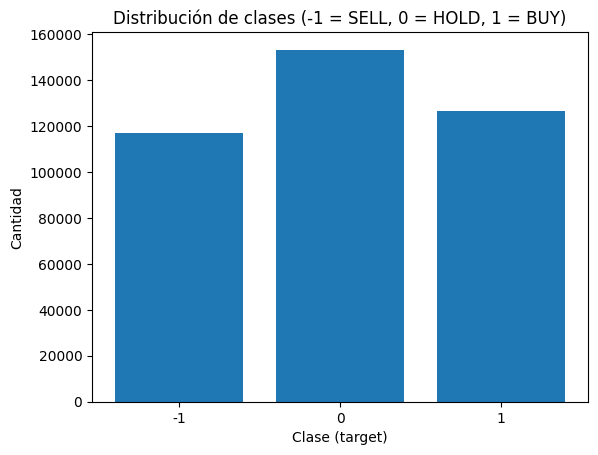

In [52]:
# Conteo de clases
def plot_targets(df):
    counts = df["target"].value_counts().sort_index()
    
    # Plot
    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    
    plt.xlabel("Clase (target)")
    plt.ylabel("Cantidad")
    plt.title("Distribución de clases (-1 = SELL, 0 = HOLD, 1 = BUY)")
    
    plt.show()
    plt.close()

for i, sp in enumerate(study_periods_data):
    df_seq = sp.get("df_sequences")
    
    print(f"Periodo {i}")  # 👈 ayuda a separar visualmente
    plot_targets(df_seq)

### Sequences dataset for Shallow Neural Network

For this neural network, we will use only 31 days back because this kind of network doenst have the ability of the lSTM networks. it cant remember large patrons

In [53]:
def build_snn_features_from_lags(df):
    """
    Convert lag-based dataset (R_-239 ... R_0) into 31 features
    following Fischer & Krauss.

    IMPORTANT:
    - The original columns (R_-k) represent individual daily returns at time t-k.
    - The new features R_k DO NOT represent single-day returns.
    - Instead, each R_k is an ACCUMULATED return over the last k days.

    Meaning:
    - R_1  = return at time t (latest return)
    - R_5  = sum of returns from t-4 to t
    - R_20 = sum of returns from t-19 to t
    - R_240 = sum of returns from t-239 to t

    So we are transforming:
        raw time series (lags)
    into:
        aggregated features (cumulative returns over different horizons)

    This is required for DNN (memory-free model), unlike LSTM,
    which uses the full sequence without aggregation.
    """

    df = df.copy()

    # windows from paper
    windows = list(range(1, 21)) + list(range(40, 241, 20))

    # get lag columns ordered correctly (oldest → newest)
    lag_cols = [col for col in df.columns if col.startswith("R_-") or col == "R_0"]

    # sort columns numerically (R_-239 ... R_0)
    lag_cols = sorted(lag_cols, key=lambda x: int(x.replace("R_", "")))

    # build accumulated features
    for w in windows:
        # take last w columns (most recent values)
        selected_cols = lag_cols[-w:]

        # cumulative return over last w days
        df[f"R_{w}"] = df[selected_cols].sum(axis=1)

    # select final columns
    feature_cols = [f"R_{w}" for w in windows]
    final_cols = feature_cols + ["ticker", "target", "date"]

    return df[final_cols]


In [54]:
for sp in study_periods_data:
    df_sequences = sp.get("df_sequences")
    df_snn = build_snn_features_from_lags(df_sequences)
    sp['df_snn'] = df_snn

In [55]:
print(f"\nStudy Period {sp['period_id']}")
df_snn = study_periods_data[0].get("df_snn")
df_snn.head()


Study Period 0


,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,R_9,R_10,...,R_120,R_140,R_160,R_180,R_200,R_220,R_240,ticker,target,date
0,-0.023962,-0.022647,-0.020341,-0.016870,-0.014219,-0.006536,0.009584,0.009584,0.018487,0.018829,...,0.271243,0.337084,0.310750,0.361964,0.382924,0.359795,0.310631,A,-1,2014-01-23
1,-0.026904,-0.050866,-0.049552,-0.047246,-0.043774,-0.041123,-0.033441,-0.017320,-0.017320,-0.008417,...,0.236953,0.285626,0.273067,0.322324,0.341373,0.337329,0.294375,A,1,2014-01-24
2,0.007431,-0.019474,-0.043436,-0.042121,-0.039815,-0.036344,-0.033692,-0.026010,-0.009889,-0.009889,...,0.253871,0.290117,0.277387,0.324631,0.310944,0.335844,0.301357,A,-1,2014-01-27
3,-0.003430,0.004000,-0.022904,-0.046866,-0.045551,-0.043245,-0.039774,-0.037123,-0.029440,-0.013320,...,0.247393,0.281277,0.283259,0.310311,0.287221,0.324972,0.295013,A,-1,2014-01-28
4,-0.007746,-0.011176,-0.003745,-0.030650,-0.054612,-0.053297,-0.050991,-0.047520,-0.044868,-0.037186,...,0.235307,0.257611,0.282891,0.316089,0.317688,0.324382,0.291066,A,-1,2014-01-29


In [56]:
df_snn.shape

(396846, 34)

In [62]:
def normalize_and_split_study_period(sp, train_days=750):
    df_seq = sp.get("df_snn").copy()
    
    # 1. Encontrar los días únicos en este bloque exacto
    unique_dates = sorted(df_seq['date'].unique())
    
    # Si por alguna razón el bloque tiene menos de 750 días, ajustamos el índice
    split_idx = min(train_days - 1, len(unique_dates) - 1)
    split_date = unique_dates[split_idx] 
    
    # 2. Separar Train y Test estrictamente por cronología
    train_df = df_seq[df_seq['date'] <= split_date].copy()
    test_df = df_seq[df_seq['date'] > split_date].copy()
    
    # 3. Obtener solo las columnas matemáticas (R_-239 a R_0)
    return_cols = [col for col in df_seq.columns if col.startswith('R_')]
    
    # 4. Calcular Z-Score SOLO con los datos del Train Set
    train_values = train_df[return_cols].values
    mu_train = train_values.mean()
    sigma_train = train_values.std()
    
    # 5. Estandarizar Train y Test usando la MISMA media y desviación
    train_df[return_cols] = (train_df[return_cols] - mu_train) / sigma_train
    test_df[return_cols] = (test_df[return_cols] - mu_train) / sigma_train
    
    # 6. Guardamos los DataFrames resultantes directo en el diccionario
    sp["df_train_norm"] = train_df
    sp["df_test_norm"] = test_df
    
    print(f"Study Period {sp['period_id']}: Train -> {len(train_df)} filas | Test -> {len(test_df)} filas | Split Date: {split_date.date()}")

# Ejecutamos la función para todos los bloques
for sp in study_periods_data:
    normalize_and_split_study_period(sp)

Study Period 0: Train -> 311161 filas | Test -> 85685 filas | Split Date: 2017-01-12


In [63]:
import os

# Crear carpeta si no existe
os.makedirs("../data/processed", exist_ok=True)

for sp in study_periods_data:
    period_id = sp['period_id']
    
    # Extraemos los dataframes limpios y separados
    df_train = sp.get("df_train_norm")
    df_test = sp.get("df_test_norm")
    
    if df_train is not None and df_test is not None:
        # Guardamos Train
        train_path = f"../data/processed/snn_train_period_{period_id}.csv"
        df_train.to_csv(train_path, index=False)
        
        # Guardamos Test
        test_path = f"../data/processed/snn_test_period_{period_id}.csv"
        df_test.to_csv(test_path, index=False)
        
print("¡Archivos .csv exportados exitosamente! Listos para la red neuronal.")

¡Archivos .csv exportados exitosamente! Listos para la red neuronal.
